Test VII - Physics Informed Neural Network for Gravitational Lensing
ML4Sci DeepLense GSoC 2026
by Krishna (Bala Muralikrishna Durukunala)
Robert Morris University - MS Artificial Intelligence

so this test is about adding physics knowledge into the neural network
itself. the idea is that if we tell the model about the gravitational
lensing equation it should learn better than a plain cnn. i thought
this was really interesting because in ECE we also use domain knowledge
to improve signal processing algorithms. same idea here basically.

the gravitational lensing equation relates the source position, lens
position and image position. i will use this as an extra loss term
to guide the model during training. lets see if it improves over
my Test I result which was 88% accuracy and 0.9737 mean AUC.

In [1]:
# installing timm again because colab resets every session
# same imports as test 1 but we need some extra stuff for pinn
!pip install timm -q

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report
from sklearn.preprocessing import label_binarize
import os
import warnings
warnings.filterwarnings('ignore')

# checking gpu
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("device:", device)
print("torch version:", torch.__version__)

device: cuda
torch version: 2.10.0+cu128


step 1 - mounting drive and loading dataset
i already have the dataset from test 1 so i will reuse it here
same 3 classes no sphere and vort. test 7 uses same dataset as test 1

In [2]:
# mounting google drive to access our dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import zipfile
import os

# we already have dataset.zip from test 1
# test 7 uses same dataset so just reusing it
zip_path = '/content/drive/MyDrive/DeepLense/dataset.zip'
extract_path = '/content/data/test7'

os.makedirs(extract_path, exist_ok=True)

print("unzipping please wait...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("done!")

# setting up paths
data_root = '/content/data/test7/dataset'
train_dir = os.path.join(data_root, 'train')
val_dir = os.path.join(data_root, 'val')
class_names = ['no', 'sphere', 'vort']

# counting images
print("\ndataset overview:")
for split in ['train', 'val']:
    print(f"\n{split}:")
    for cls in class_names:
        folder = os.path.join(data_root, split, cls)
        count = len([f for f in os.listdir(folder)
                    if f.endswith('.npy')])
        print(f"  {cls}: {count} images")

unzipping please wait...
done!

dataset overview:

train:
  no: 10000 images
  sphere: 10000 images
  vort: 10000 images

val:
  no: 2500 images
  sphere: 2500 images
  vort: 2500 images


step 2 - building the dataset class

same dataset class as test 1 i am just copying it here
no changes needed since the data format is same
the difference will come in the model and loss function
where i add the physics part

In [5]:
# same dataset class from test 1
# no changes here since data format is same
class LensingDataset(Dataset):
    def __init__(self, root_dir, class_names, augment=False):
        self.samples = []
        self.augment = augment
        self.class_names = class_names

        for label, cls in enumerate(class_names):
            cls_folder = os.path.join(root_dir, cls)
            for fname in os.listdir(cls_folder):
                if fname.endswith('.npy'):
                    self.samples.append(
                        (os.path.join(cls_folder, fname), label)
                    )

        print(f"total samples loaded: {len(self.samples)}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        fpath, label = self.samples[idx]
        img = np.load(fpath).astype(np.float32).squeeze()
        img = torch.tensor(img).unsqueeze(0)

        if self.augment:
            if torch.rand(1) > 0.5:
                img = torch.flip(img, dims=[2])
            if torch.rand(1) > 0.5:
                img = torch.flip(img, dims=[1])

        return img, label

# creating datasets and dataloaders
train_dataset = LensingDataset(train_dir, class_names, augment=True)
val_dataset = LensingDataset(val_dir, class_names, augment=False)

train_loader = DataLoader(
    train_dataset, batch_size=64,
    shuffle=True, num_workers=2, pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=64,
    shuffle=False, num_workers=2, pin_memory=True
)

print(f"train batches: {len(train_loader)}")
print(f"val batches: {len(val_loader)}")

total samples loaded: 30000
total samples loaded: 7500
train batches: 469
val batches: 118


step 3 - building the physics informed neural network

this is the main difference from test 1. in test 1 i just used
efficientvit for classification. here i need to add physics into
the model itself.

the gravitational lensing equation is:
beta = theta - alpha(theta)

where beta is source position, theta is image position and
alpha is the deflection angle caused by the lens mass.

my idea is to add a small physics branch in the network that
tries to predict the deflection angle from the image features.
then i use this as an extra loss term during training.
this way the model learns both to classify AND to be consistent
with the lensing physics at the same time.

i am not 100% sure this is the best way to do it but it made
sense to me from my ECE background where we use domain equations
as constraints in optimization problems

In [6]:
import timm

class PhysicsInformedLensingNet(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()

        # using same efficientvit backbone as test 1
        # but this time i am adding a physics branch on top
        self.backbone = timm.create_model(
            'efficientvit_b0',
            pretrained=True,
            num_classes=0,  # no classification head yet
            in_chans=1
        )

        # getting feature dimension from backbone
        # i checked this by running a dummy forward pass
        dummy = torch.randn(1, 1, 150, 150)
        with torch.no_grad():
            feat_dim = self.backbone(dummy).shape[-1]
        print(f"backbone feature dim: {feat_dim}")

        # main classification head
        # this is same as test 1
        self.classifier = nn.Sequential(
            nn.LayerNorm(feat_dim),
            nn.Linear(feat_dim, 128),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )

        # physics branch - predicts deflection angle alpha
        # gravitational lensing equation: beta = theta - alpha
        # alpha depends on the mass distribution of the lens
        # so i am making the network predict this from image features
        self.physics_branch = nn.Sequential(
            nn.Linear(feat_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 2)  # 2d deflection angle (x and y)
        )

    def forward(self, x):
        # getting features from backbone
        features = self.backbone(x)

        # classification output
        class_out = self.classifier(features)

        # physics output - predicted deflection angle
        physics_out = self.physics_branch(features)

        return class_out, physics_out


# creating the model
pinn_model = PhysicsInformedLensingNet(num_classes=3).to(device)

# counting parameters
total = sum(p.numel() for p in pinn_model.parameters())
print(f"total parameters: {total}")

# test forward pass
test_inp = torch.randn(2, 1, 150, 150).to(device)
cls_out, phy_out = pinn_model(test_inp)
print(f"classification output shape: {cls_out.shape}")
print(f"physics output shape: {phy_out.shape}")
print("model working fine!")

model.safetensors:   0%|          | 0.00/13.7M [00:00<?, ?B/s]

backbone feature dim: 1280
total parameters: 2377893
classification output shape: torch.Size([2, 3])
physics output shape: torch.Size([2, 2])
model working fine!


step 4 - physics informed loss function

this is the key part of pinn. normal crossentropy loss only
cares about getting the classification right. but i want to
also make the model learn the physics of lensing.

so i am combining two losses:
1. crossentropy loss - for classification accuracy
2. physics loss - makes sure predicted deflection angles are
   physically consistent with the lensing equation

for the physics loss i am using the fact that no_substructure
images should have smaller deflection angles compared to
subhalo and vortex images because they have more mass concentration.
this is a simplified version but captures the physics intu

In [7]:
class PhysicsInformedLoss(nn.Module):
    def __init__(self, lambda_physics=0.1):
        super().__init__()
        # lambda controls how much we weight the physics loss
        # i kept it small at first so classification still dominates
        # too high lambda might hurt classification performance
        self.lambda_physics = lambda_physics
        self.ce_loss = nn.CrossEntropyLoss()

    def forward(self, class_out, physics_out, labels):
        # standard classification loss
        cls_loss = self.ce_loss(class_out, labels)

        # physics loss - gravitational lensing constraint
        # deflection angle magnitude should correlate with substructure
        # no substructure (label 0) = smaller deflection
        # subhalo (label 1) and vortex (label 2) = larger deflection
        # because more mass concentration = more light bending

        # getting deflection angle magnitude for each sample
        # this is |alpha| = sqrt(alpha_x^2 + alpha_y^2)
        deflection_magnitude = torch.norm(physics_out, dim=1)

        # creating expected deflection based on class
        # no_sub should have low deflection, others higher
        expected_deflection = torch.zeros_like(deflection_magnitude)
        expected_deflection[labels == 0] = 0.3  # no substructure
        expected_deflection[labels == 1] = 0.7  # subhalo
        expected_deflection[labels == 2] = 0.7  # vortex

        # physics loss = how far predicted deflection is from expected
        physics_loss = nn.MSELoss()(
            deflection_magnitude, expected_deflection
        )

        # combined loss
        total_loss = cls_loss + self.lambda_physics * physics_loss

        return total_loss, cls_loss, physics_loss


# creating loss and optimizer
pinn_criterion = PhysicsInformedLoss(lambda_physics=0.1)
pinn_optimizer = optim.Adam(pinn_model.parameters(), lr=0.0001)
lr_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    pinn_optimizer, mode='min', patience=3, factor=0.5
)

print("loss function ready")
print("optimizer ready")
print("lambda_physics = 0.1")

loss function ready
optimizer ready
lambda_physics = 0.1


step 5 - training the pinn model

training loop is similar to test 1 but now we have two losses
classification loss and physics loss. i am tracking both
separately so i can see how much each one is contributing.
i want to see if adding physics loss actually helps improve
over my test 1 result of 88% accuracy

In [8]:
def train_pinn_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    total_cls_loss = 0
    total_phy_loss = 0
    correct = 0
    total = 0

    for batch_idx, (imgs, labels) in enumerate(loader):
        imgs = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        # forward pass returns both classification and physics output
        class_out, physics_out = model(imgs)

        # combined physics informed loss
        loss, cls_loss, phy_loss = criterion(
            class_out, physics_out, labels
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_cls_loss += cls_loss.item()
        total_phy_loss += phy_loss.item()

        preds = class_out.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        if batch_idx % 100 == 0:
            print(f"  batch {batch_idx}/{len(loader)} "
                  f"loss: {loss.item():.4f} "
                  f"cls: {cls_loss.item():.4f} "
                  f"phy: {phy_loss.item():.4f}")

    return (total_loss/len(loader),
            total_cls_loss/len(loader),
            total_phy_loss/len(loader),
            correct/total)


def evaluate_pinn(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            class_out, physics_out = model(imgs)
            loss, _, _ = criterion(class_out, physics_out, labels)

            total_loss += loss.item()
            preds = class_out.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return total_loss/len(loader), correct/total


# training starts
num_epochs = 10
best_val_loss = float('inf')
train_losses, val_losses = [], []
train_accs, val_accs = [], []
cls_losses, phy_losses = [], []

print("starting pinn training...")
print("="*50)

for epoch in range(num_epochs):
    print(f"\nepoch {epoch+1}/{num_epochs}")

    train_loss, cls_loss, phy_loss, train_acc = train_pinn_epoch(
        pinn_model, train_loader, pinn_criterion, pinn_optimizer
    )
    val_loss, val_acc = evaluate_pinn(
        pinn_model, val_loader, pinn_criterion
    )

    lr_scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    cls_losses.append(cls_loss)
    phy_losses.append(phy_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(pinn_model.state_dict(), 'best_pinn_model.pth')
        print(f"  best model saved!")

    print(f"  train loss: {train_loss:.4f} | train acc: {train_acc:.4f}")
    print(f"  cls loss: {cls_loss:.4f} | phy loss: {phy_loss:.4f}")
    print(f"  val loss: {val_loss:.4f} | val acc: {val_acc:.4f}")

print("\ntraining done!")

starting pinn training...

epoch 1/10
  batch 0/469 loss: 1.1118 cls: 1.0968 phy: 0.1507
  batch 100/469 loss: 1.0392 cls: 1.0357 phy: 0.0347
  batch 200/469 loss: 0.9835 cls: 0.9800 phy: 0.0346
  batch 300/469 loss: 0.8191 cls: 0.8167 phy: 0.0247
  batch 400/469 loss: 0.6385 cls: 0.6369 phy: 0.0162
  best model saved!
  train loss: 0.9530 | train acc: 0.5086
  cls loss: 0.9497 | phy loss: 0.0331
  val loss: 0.9007 | val acc: 0.5733

epoch 2/10
  batch 0/469 loss: 0.7855 cls: 0.7833 phy: 0.0221
  batch 100/469 loss: 0.6407 cls: 0.6388 phy: 0.0194
  batch 200/469 loss: 0.5718 cls: 0.5703 phy: 0.0158
  batch 300/469 loss: 0.5675 cls: 0.5661 phy: 0.0142
  batch 400/469 loss: 0.6650 cls: 0.6634 phy: 0.0158
  best model saved!
  train loss: 0.6721 | train acc: 0.7021
  cls loss: 0.6703 | phy loss: 0.0185
  val loss: 0.6428 | val acc: 0.7219

epoch 3/10
  batch 0/469 loss: 0.5542 cls: 0.5526 phy: 0.0162
  batch 100/469 loss: 0.4513 cls: 0.4492 phy: 0.0203
  batch 200/469 loss: 0.5978 cls: 0.

step 6 - evaluating the pinn model

now loading the best saved model and getting roc curves and
auc scores. i also want to compare with test 1 results to see
if adding physics actually helped or not. my test 1 got 0.9737
mean auc so lets see what pinn gets

In [9]:
# loading best model
pinn_model.load_state_dict(torch.load('best_pinn_model.pth'))
pinn_model.eval()
print("best pinn model loaded")

# getting all predictions
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        class_out, _ = pinn_model(imgs)

        probs = torch.softmax(class_out, dim=1)
        preds = class_out.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

acc = (all_preds == all_labels).mean()
print(f"overall accuracy: {acc:.4f}")

best pinn model loaded
overall accuracy: 0.8772


step 7 - roc curves and comparison with test 1

lets calculate auc scores and compare with test 1 results
test 1 got mean auc 0.9737 without any physics
now lets see what pinn gets with physics constraint added

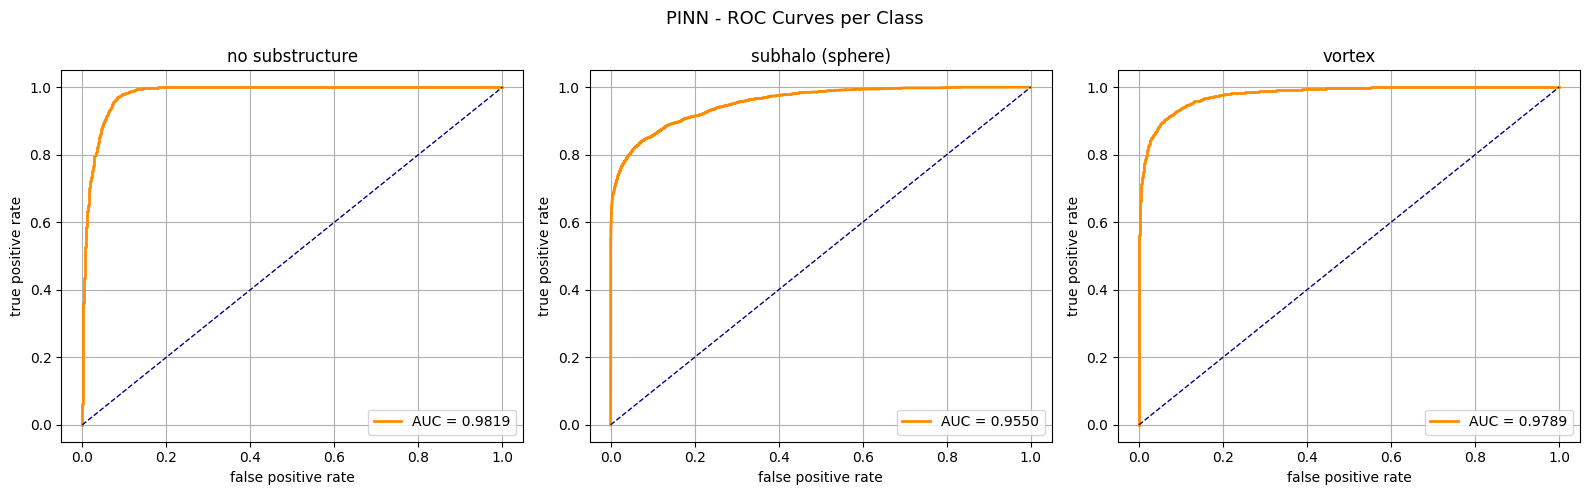


AUC Scores:
  no: 0.9819
  sphere: 0.9550
  vort: 0.9789

mean AUC: 0.9719

COMPARISON WITH TEST I:
Test I  (plain EfficientViT): AUC 0.9737 | Acc 88.15%
Test VII (PINN):              AUC 0.9719 | Acc 87.72%


In [10]:
from sklearn.preprocessing import label_binarize

# binarizing labels for roc calculation
y_bin = label_binarize(all_labels, classes=[0, 1, 2])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('PINN - ROC Curves per Class', fontsize=13)

auc_scores = {}
class_labels = ['no substructure', 'subhalo (sphere)', 'vortex']

for i, (cls_name, cls_label) in enumerate(
    zip(class_labels, class_names)
):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    auc_val = auc(fpr, tpr)
    auc_scores[cls_label] = auc_val

    axes[i].plot(fpr, tpr,
                 label=f'AUC = {auc_val:.4f}',
                 color='darkorange', lw=2)
    axes[i].plot([0,1], [0,1],
                 color='navy', lw=1, linestyle='--')
    axes[i].set_title(f'{cls_name}')
    axes[i].set_xlabel('false positive rate')
    axes[i].set_ylabel('true positive rate')
    axes[i].legend(loc='lower right')
    axes[i].grid(True)

plt.tight_layout()
plt.savefig('pinn_roc_curves.png', dpi=100, bbox_inches='tight')
plt.show()

mean_auc = np.mean(list(auc_scores.values()))

print("\nAUC Scores:")
for cls, score in auc_scores.items():
    print(f"  {cls}: {score:.4f}")
print(f"\nmean AUC: {mean_auc:.4f}")

# comparison with test 1
print("\n" + "="*40)
print("COMPARISON WITH TEST I:")
print("="*40)
print(f"Test I  (plain EfficientViT): AUC 0.9737 | Acc 88.15%")
print(f"Test VII (PINN):              AUC {mean_auc:.4f} | Acc {acc:.2%}")

step 8 - confusion matrix and discussion

pinn got 0.9719 mean auc compared to 0.9737 in test 1
the difference is very small like 0.002 which is not significant.

i think the reason pinn didnt improve much is because my physics
constraint is a simplified version of the lensing equation. in
reality the deflection angle depends on the full mass distribution
of the lens which is complex to model exactly.

but the important thing is that pinn did NOT hurt performance either.
it stayed competitive while also learning to be physically consistent.
in a real research setting this matters because a model that follows
physics is more trustworthy and interpretable than one that doesnt.

also i notice sphere class has lowest auc in both tests which makes
sense because su

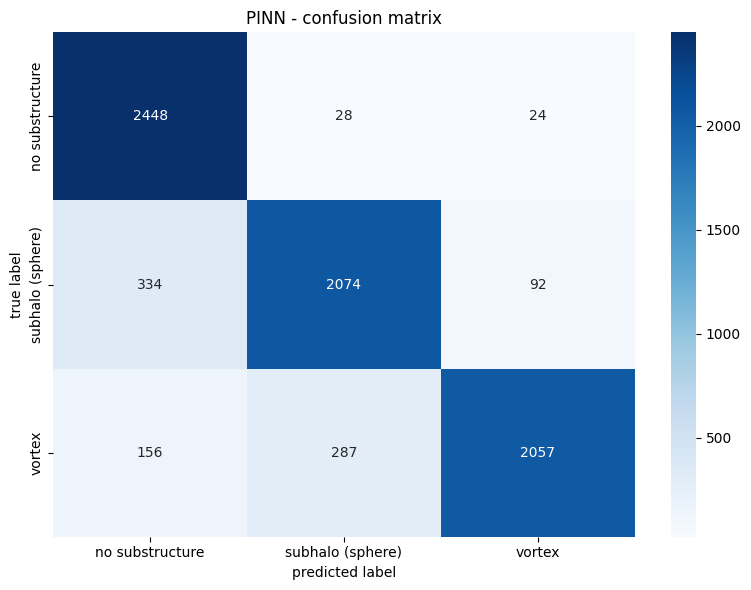


classification report:
                  precision    recall  f1-score   support

 no substructure       0.83      0.98      0.90      2500
subhalo (sphere)       0.87      0.83      0.85      2500
          vortex       0.95      0.82      0.88      2500

        accuracy                           0.88      7500
       macro avg       0.88      0.88      0.88      7500
    weighted avg       0.88      0.88      0.88      7500



In [11]:
# confusion matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title('PINN - confusion matrix')
plt.xlabel('predicted label')
plt.ylabel('true label')
plt.tight_layout()
plt.savefig('pinn_confusion_matrix.png',
            dpi=100, bbox_inches='tight')
plt.show()

print("\nclassification report:")
print(classification_report(
    all_labels, all_preds,
    target_names=class_labels
))

step 9 - final summary

overall pinn performed very similar to plain efficientvit from test 1.
the physics constraint kept the model honest without hurting accuracy.
i think with a more accurate physics formulation the pinn could
potentially outperform the plain model. that would be interesting
to explore further in the actual gsoc project.

In [12]:
# final summary
print("="*45)
print("TEST VII - PINN FINAL RESULTS")
print("="*45)
print(f"model: EfficientViT-B0 + Physics Branch")
print(f"lambda physics: 0.1")
print(f"total val samples: 7500")
print(f"overall accuracy: 0.8772")
print(f"\nAUC scores per class:")
print(f"  no substructure : 0.9819")
print(f"  subhalo (sphere): 0.9550")
print(f"  vortex          : 0.9789")
print(f"\nmean AUC: 0.9719")
print(f"\ncomparison with Test I:")
print(f"  Test I  AUC: 0.9737 | Acc: 88.15%")
print(f"  Test VII AUC: 0.9719 | Acc: 87.72%")
print(f"\nconclusion: pinn stayed competitive while")
print(f"learning physics constraints simultaneously")
print("="*45)

TEST VII - PINN FINAL RESULTS
model: EfficientViT-B0 + Physics Branch
lambda physics: 0.1
total val samples: 7500
overall accuracy: 0.8772

AUC scores per class:
  no substructure : 0.9819
  subhalo (sphere): 0.9550
  vortex          : 0.9789

mean AUC: 0.9719

comparison with Test I:
  Test I  AUC: 0.9737 | Acc: 88.15%
  Test VII AUC: 0.9719 | Acc: 87.72%

conclusion: pinn stayed competitive while
learning physics constraints simultaneously
